# 02 — Explore
Load the processed dataset and run sanity checks and diagnostic plots.

In [11]:
import sys, yaml
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
sys.path.insert(0, '..')

In [12]:
config = yaml.safe_load(open('../config/GI03FLMA-RIM01-02-ADCPSL003.yaml'))
refdes = config['refdes']
ds = xr.open_dataset(f'../data/{refdes}.nc').load()
ds

<xarray.Dataset>
Dimensions:                                       (time: 77991, bin_depths: 51,
                                                   beam: 4)
Coordinates:
  * time                                          (time) datetime64[ns] 2014-...
  * bin_depths                                    (bin_depths) float64 500.0 ...
  * beam                                          (beam) int8 1 2 3 4
    station                                       <U27 'GI03FLMA-RIM01-02-ADC...
Data variables: (12/37)
    percent_bad_beams                             (time, bin_depths) float64 ...
    percent_transforms_reject                     (time, bin_depths) float64 ...
    error_sea_water_velocity                      (time, bin_depths) float64 ...
    percent_good_4beam                            (time, bin_depths) float64 ...
    water_velocity_north                          (time, bin_depths) float64 ...
    percent_good_3beam                            (time, bin_depths) float64 ...
    ...                                            ...
    eastward_sea_water_velocity_qartod_results    (time, bin_depths) int8 9 ....
    northward_sea_water_velocity_qartod_executed  (time, bin_depths) object '...
    northward_sea_water_velocity_qartod_results   (time, bin_depths) int8 9 ....
    echo_intensity                                (beam, time, bin_depths) float64 ...
    corrected_echo_intensity                      (beam, time, bin_depths) float64 ...
    correlation_magnitude                         (beam, time, bin_depths) float64 ...
Attributes: (12/36)
    title:                           Global Irminger Sea : Flanking Subsurfac...
    comment:                         Data produced by the OOI M2M API and rew...
    sourceUrl:                       http://oceanobservatories.org/
    featureType:                     timeSeriesProfile
    publisher_name:                  Ocean Observatories Initiative
    references:                      More information can be found at http://...
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  0.1
    geospatial_vertical_positive:    down
    lat:                             59.76805
    lon:                             -39.84252
    Conventions:                     CF-1.11

## Dataset overview

In [13]:
print('Dimensions:', dict(ds.sizes))
print('Time range:', ds.time.values[0], '→', ds.time.values[-1])
print('Depth range:', ds.bin_depths.values.min(), '–', ds.bin_depths.values.max(), 'm')
print('Variables:', list(ds.data_vars))

Dimensions: {'time': 77991, 'bin_depths': 51, 'beam': 4}
Time range: 2014-09-12T21:00:00.000000000 → 2023-09-09T11:00:00.000000000
Depth range: 0.0 – 500.0 m
Variables: ['percent_bad_beams', 'percent_transforms_reject', 'error_sea_water_velocity', 'percent_good_4beam', 'water_velocity_north', 'percent_good_3beam', 'eastward_sea_water_velocity', 'water_velocity_up', 'water_velocity_east', 'upward_sea_water_velocity', 'northward_sea_water_velocity', 'error_velocity', 'earth_error_velocity', 'upward_earth_sea_water_velocity', 'qc_flags', 'pitch', 'cell_length', 'heading', 'roll', 'deployment', 'bin_1_distance', 'serial_number', 'sea_water_temperature', 'sea_water_practical_salinity', 'sea_water_pressure', 'sound_speed', 'sea_water_temperature_qartod_executed', 'sea_water_temperature_qartod_results', 'sea_water_practical_salinity_qartod_executed', 'sea_water_practical_salinity_qartod_results', 'eastward_sea_water_velocity_qartod_executed', 'eastward_sea_water_velocity_qartod_results', 'nor

## Velocity time-depth plots

In [30]:
def insert_gap_nans(times, data, max_gap_hours=12):
    """
    Insert NaN columns into a (bin, time) array wherever the time gap between
    consecutive timesteps exceeds max_gap_hours, preventing pcolormesh from
    interpolating across gaps.

    Returns new_times, new_data arrays with NaN columns inserted.
    """
    times_num  = times.astype("int64")
    diffs      = np.diff(times_num)
    threshold  = np.timedelta64(max_gap_hours, "h").astype("int64")
    gap_idx    = np.where(diffs > threshold)[0]  # indices just before each gap

    if len(gap_idx) == 0:
        return times, data

    # Build output by inserting NaN slices at each gap
    new_times  = []
    new_data   = []
    prev        = 0
    nan_col     = np.full((data.shape[0], 1), np.nan)
    nan_time    = np.array([times[gap_idx[0]]], dtype=times.dtype)  # placeholder time

    for gi in gap_idx:
        new_times.append(times[prev:gi + 1])
        new_data.append(data[:, prev:gi + 1])
        # Insert a NaN column with a time halfway across the gap
        mid_time = times_num[gi] + diffs[gi] // 2
        new_times.append(np.array([mid_time], dtype=times_num.dtype).astype(times.dtype))
        new_data.append(nan_col)
        prev = gi + 1

    new_times.append(times[prev:])
    new_data.append(data[:, prev:])

    return np.concatenate(new_times), np.hstack(new_data)

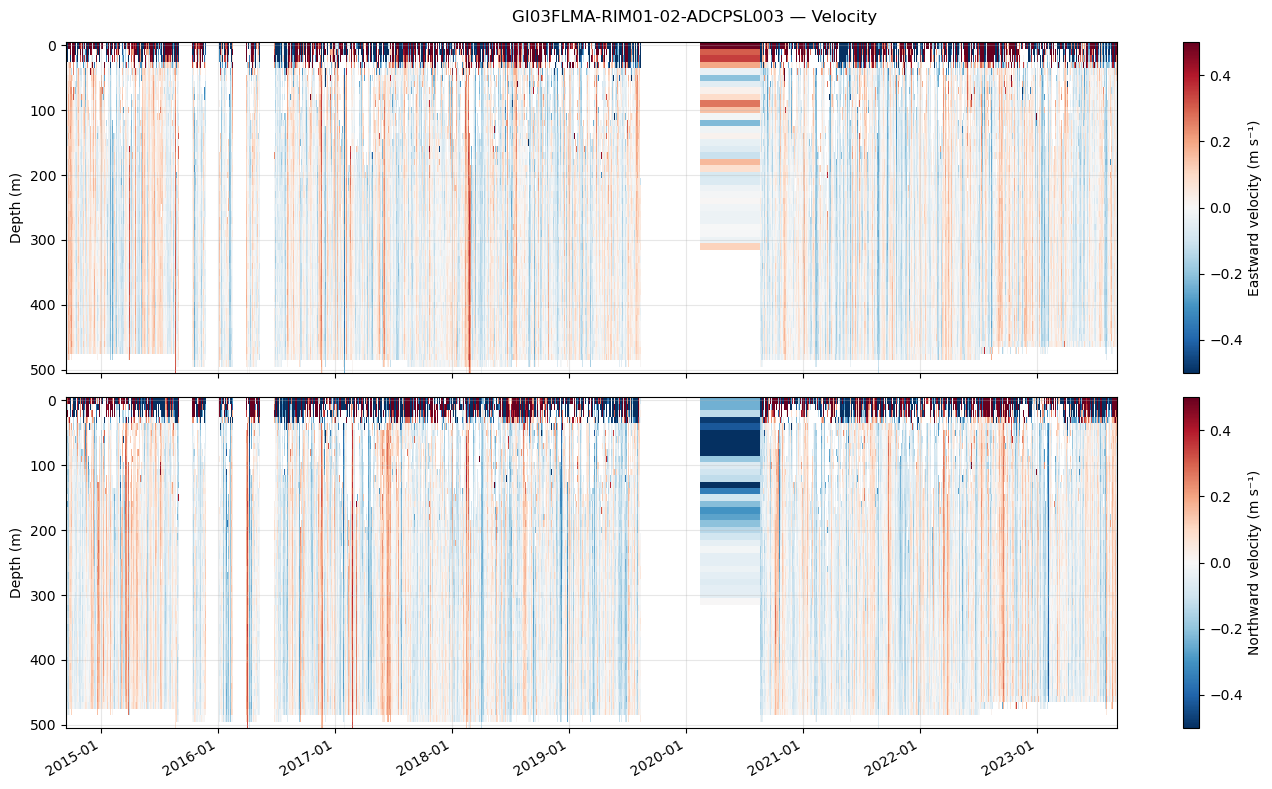

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, var, label in zip(
    axes,
    ['eastward_sea_water_velocity', 'northward_sea_water_velocity'],
    ['Eastward velocity (m s⁻¹)', 'Northward velocity (m s⁻¹)'],
):
    p = ax.pcolormesh(
        ds.time.values, ds.bin_depths.values,
        ds[var].values.T,
        cmap='RdBu_r', vmin=-0.5, vmax=0.5,
    )
    plt.colorbar(p, ax=ax, label=label)
    ax.set_ylabel('Depth (m)')
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(alpha=0.3)

fig.suptitle(f'{refdes} — Velocity', fontsize=12)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

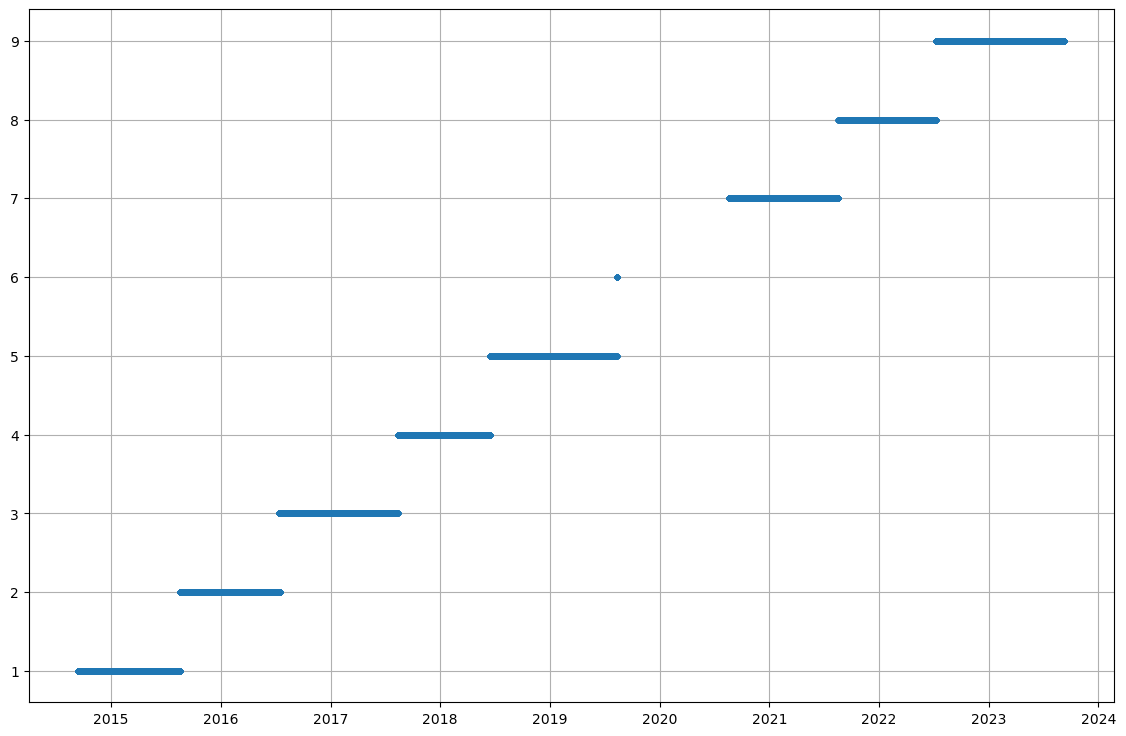

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(14,9))

ax.plot(ds.time.values, ds.deployment.values, marker='.', linestyle='')
ax.grid()

## CTD scalar variables

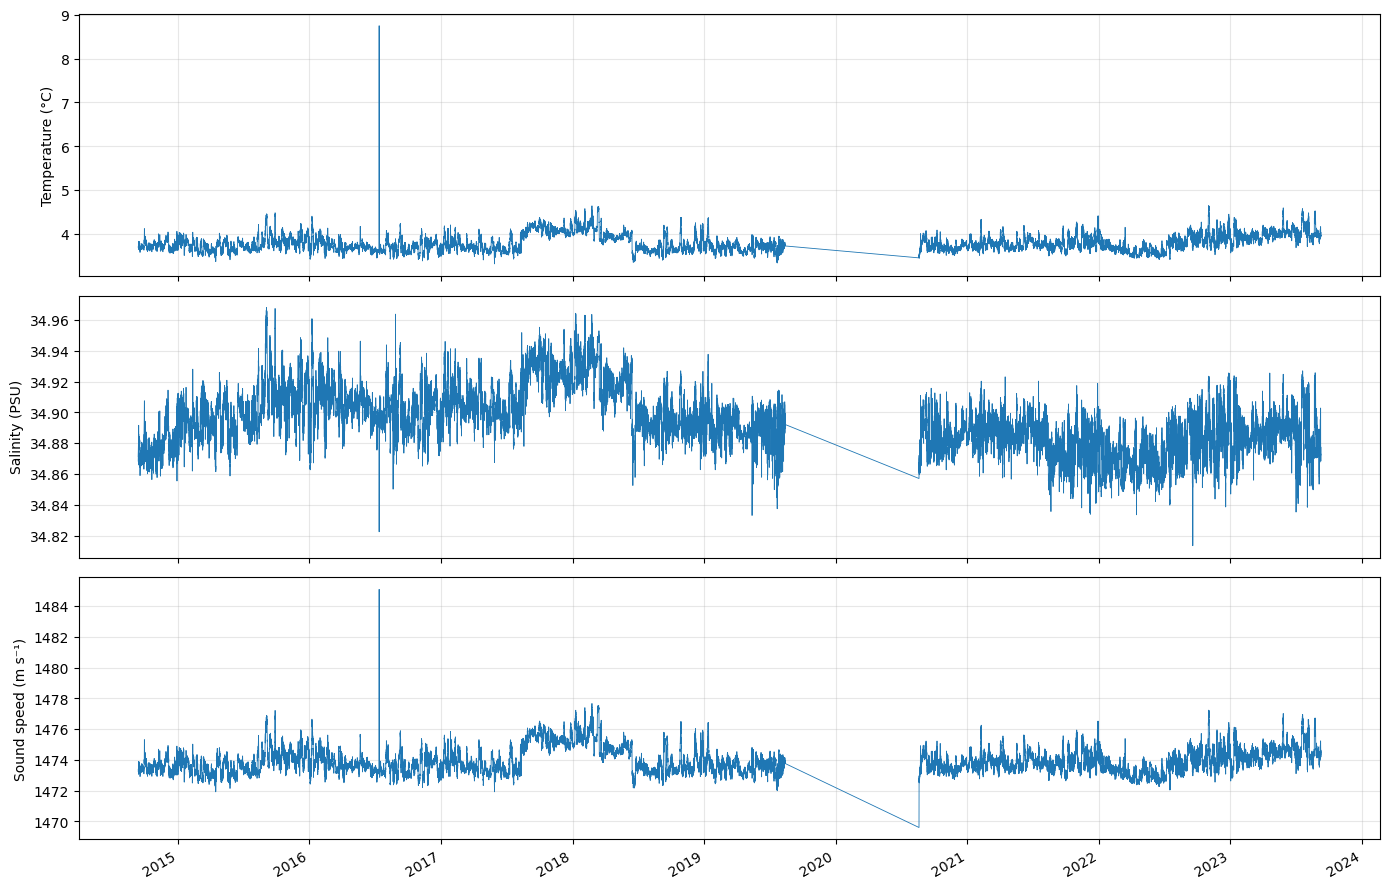

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, var, label in zip(
    axes,
    ['sea_water_temperature', 'sea_water_practical_salinity', 'sound_speed'],
    ['Temperature (°C)', 'Salinity (PSU)', 'Sound speed (m s⁻¹)'],
):
    ax.plot(ds.time.values, ds[var].values, lw=0.6)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

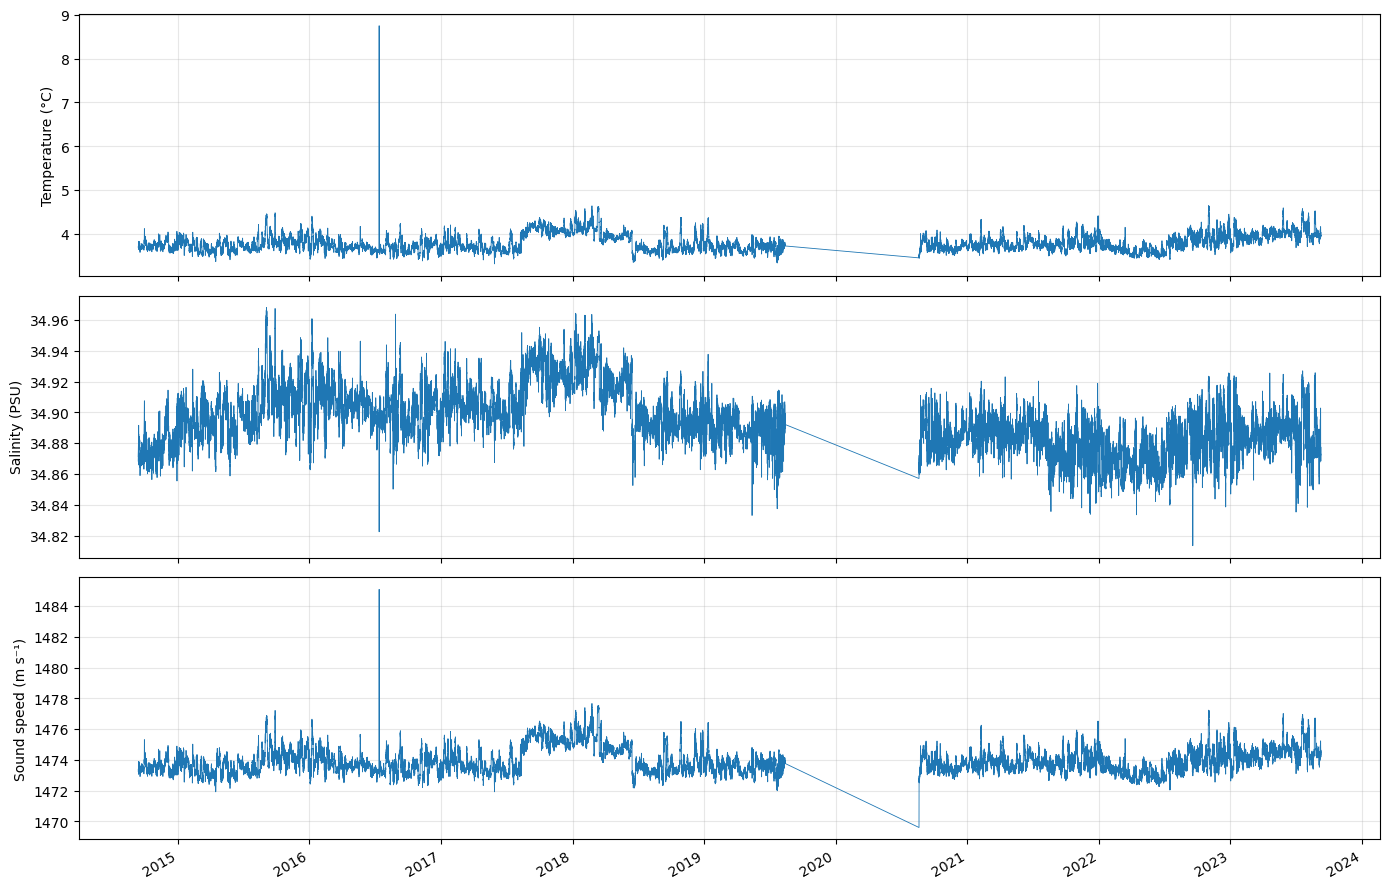

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

for ax, var, label in zip(
    axes,
    ['sea_water_temperature', 'sea_water_practical_salinity', 'sound_speed'],
    ['Temperature (°C)', 'Salinity (PSU)', 'Sound speed (m s⁻¹)'],
):
    ax.plot(ds.time.values, ds[var].values, lw=0.6)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## QARTOD flag coverage

In [17]:
for var in ['sea_water_temperature_qartod_results', 'sea_water_practical_salinity_qartod_results',
             'eastward_sea_water_velocity_qartod_results', 'northward_sea_water_velocity_qartod_results']:
    if var not in ds:
        continue
    flags = ds[var].values.ravel()
    total = flags.size
    print(f'\n{var}')
    for flag, meaning in [(1,'pass'),(3,'suspect'),(4,'fail'),(9,'missing')]:
        n = (flags == flag).sum()
        print(f'  {flag} ({meaning:8s}): {n:>8,}  ({100*n/total:.1f}%)')


sea_water_temperature_qartod_results
  1 (pass    ):   74,618  (95.7%)
  3 (suspect ):    3,373  (4.3%)
  4 (fail    ):        0  (0.0%)
  9 (missing ):        0  (0.0%)

sea_water_practical_salinity_qartod_results
  1 (pass    ):   74,373  (95.4%)
  3 (suspect ):    3,618  (4.6%)
  4 (fail    ):        0  (0.0%)
  9 (missing ):        0  (0.0%)

eastward_sea_water_velocity_qartod_results
  1 (pass    ): 3,159,339  (79.4%)
  3 (suspect ):   20,621  (0.5%)
  4 (fail    ):       19  (0.0%)
  9 (missing ):  797,562  (20.1%)

northward_sea_water_velocity_qartod_results
  1 (pass    ): 3,156,772  (79.4%)
  3 (suspect ):   23,186  (0.6%)
  4 (fail    ):       21  (0.0%)
  9 (missing ):  797,562  (20.1%)


## Echo intensity — first beam

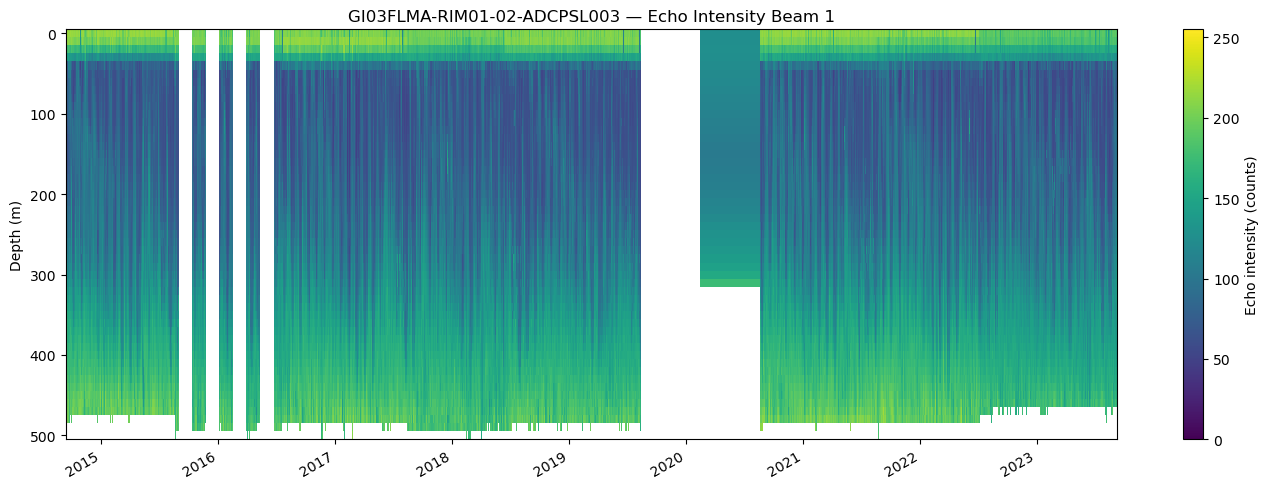

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))
p = ax.pcolormesh(
    ds.time.values, ds.bin_depths.values,
    ds['echo_intensity'].sel(beam=1).values.T,
    cmap='viridis', vmin=0, vmax=255,
)
plt.colorbar(p, ax=ax, label='Echo intensity (counts)')
ax.set_ylabel('Depth (m)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title(f'{refdes} — Echo Intensity Beam 1')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [23]:
check = ds.sel(time=slice('2019-09-01','2020-08-01'))
check

<xarray.Dataset>
Dimensions:                                       (time: 0, bin_depths: 51,
                                                   beam: 4)
Coordinates:
  * time                                          (time) datetime64[ns] 
  * bin_depths                                    (bin_depths) float64 500.0 ...
  * beam                                          (beam) int8 1 2 3 4
    station                                       <U27 'GI03FLMA-RIM01-02-ADC...
Data variables: (12/37)
    percent_bad_beams                             (time, bin_depths) float64 
    percent_transforms_reject                     (time, bin_depths) float64 
    error_sea_water_velocity                      (time, bin_depths) float64 
    percent_good_4beam                            (time, bin_depths) float64 
    water_velocity_north                          (time, bin_depths) float64 
    percent_good_3beam                            (time, bin_depths) float64 
    ...                                            ...
    eastward_sea_water_velocity_qartod_results    (time, bin_depths) int8 
    northward_sea_water_velocity_qartod_executed  (time, bin_depths) object 
    northward_sea_water_velocity_qartod_results   (time, bin_depths) int8 
    echo_intensity                                (beam, time, bin_depths) float64 ...
    corrected_echo_intensity                      (beam, time, bin_depths) float64 ...
    correlation_magnitude                         (beam, time, bin_depths) float64 ...
Attributes: (12/36)
    title:                           Global Irminger Sea : Flanking Subsurfac...
    comment:                         Data produced by the OOI M2M API and rew...
    sourceUrl:                       http://oceanobservatories.org/
    featureType:                     timeSeriesProfile
    publisher_name:                  Ocean Observatories Initiative
    references:                      More information can be found at http://...
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  0.1
    geospatial_vertical_positive:    down
    lat:                             59.76805
    lon:                             -39.84252
    Conventions:                     CF-1.11

In [19]:
deployments = np.unique(ds.deployment)
dtimes = []
for dn in deployments:
    idx, = np.where(ds['deployment'] == dn)
    tstart = ds['time'].values[idx[0]]
    tend = ds['time'].values[idx[-1]]
    dtimes.append((dn, tstart, tend))

In [20]:
dtimes

[(1,
  numpy.datetime64('2014-09-12T21:00:00.000000000'),
  numpy.datetime64('2015-08-18T10:00:00.000000000')),
 (2,
  numpy.datetime64('2015-08-19T00:37:14.969999872'),
  numpy.datetime64('2016-07-17T09:37:14.970000384')),
 (3,
  numpy.datetime64('2016-07-12T16:00:00.000000000'),
  numpy.datetime64('2017-08-12T11:00:00.000000000')),
 (4,
  numpy.datetime64('2017-08-12T12:00:00.000000000'),
  numpy.datetime64('2018-06-15T09:00:00.000000000')),
 (5,
  numpy.datetime64('2018-06-15T10:00:00.000000000'),
  numpy.datetime64('2019-08-11T10:00:00.000000000')),
 (6,
  numpy.datetime64('2019-08-11T11:00:00.000000000'),
  numpy.datetime64('2019-08-14T01:00:00.000000000')),
 (7,
  numpy.datetime64('2020-08-19T15:00:00.000000000'),
  numpy.datetime64('2021-08-18T08:00:00.000000000')),
 (8,
  numpy.datetime64('2021-08-18T09:00:00.000000000'),
  numpy.datetime64('2022-07-08T14:00:00.000000000')),
 (9,
  numpy.datetime64('2022-07-08T15:00:00.000000000'),
  numpy.datetime64('2023-09-09T11:00:00.000000

## Clean Up
Based on human-in-the-loop review, cleanup the remaining dataset 